In [52]:
import pandas as pd

df = pd.read_csv("customer_churn_nn.csv")

print(df.head())

  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3                   1   

In [53]:
print(df.shape)

(2000, 17)


In [54]:
print(df.dtypes)

customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [55]:
print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [56]:
print(df.describe())

       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000            0.000000       0.

Target column: churn
churn
0    1969
1      31
Name: count, dtype: int64
churn
0    98.45
1     1.55
Name: count, dtype: float64


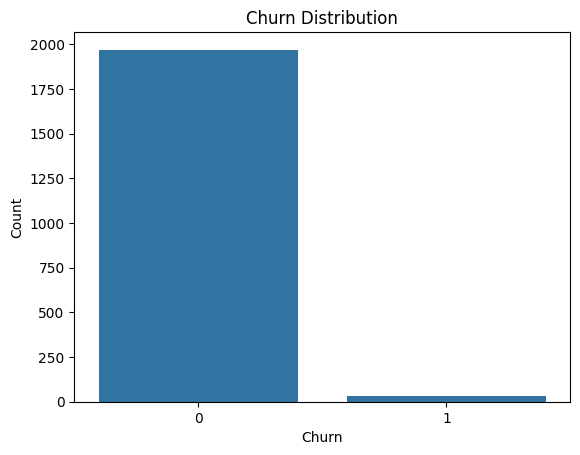

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Target column: churn")

counts = df['churn'].value_counts()
print(counts)

percentages = (counts / len(df)) * 100
print(percentages)

sns.countplot(x='churn', data=df)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(8, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\saksh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 16)             │           464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609 (2.38 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("customer_churn_nn.csv")

df = df.drop("customer_id", axis=1)

df = df.fillna(df.median(numeric_only=True))

df = pd.get_dummies(df)

X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1600, 28)
X_test shape: (400, 28)


In [46]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

train_loss, train_accuracy = model.evaluate(X_train, y_train)

print("Training Loss:", train_loss)
print("Training Accuracy:", train_accuracy)

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Testing Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4617 - loss: 0.7835 - val_accuracy: 0.8125 - val_loss: 0.5531
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8961 - loss: 0.4292 - val_accuracy: 0.9719 - val_loss: 0.3298
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9828 - loss: 0.2603 - val_accuracy: 0.9781 - val_loss: 0.2190
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1697 - val_accuracy: 0.9781 - val_loss: 0.1603
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.1216 - val_accuracy: 0.9781 - val_loss: 0.1310
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0968 - val_accuracy: 0.9781 - val_loss: 0.1170
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0839 - val_accuracy: 0.9781 - val_loss: 0.1105
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0764 - val_accuracy: 0.9781 - val_loss:

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Model 1
model1 = Sequential()

model1.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
model1.add(Dense(8, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

loss1, acc1 = model1.evaluate(X_test, y_test)

print("Experiment 1 Accuracy:", acc1)

Epoch 1/20


c:\Users\saksh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9867 - loss: 0.1954 - val_accuracy: 0.9781 - val_loss: 0.1706
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1214 - val_accuracy: 0.9781 - val_loss: 0.1280
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0896 - val_accuracy: 0.9781 - val_loss: 0.1124
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0763 - val_accuracy: 0.9781 - val_loss: 0.1064
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0697 - val_accuracy: 0.9781 - val_loss: 0.1043
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0653 - val_accuracy: 0.9781 - val_loss: 0.1033
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0620 - val_accuracy: 0.9781 - val_loss: 0.1026
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0593 - val_accuracy: 0.9781 - val_loss: 0.1025
Epo

In [48]:
# Model 2
model2 = Sequential()

model2.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

loss2, acc2 = model2.evaluate(X_test, y_test)

print("Experiment 2 Accuracy:", acc2)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5461 - loss: 0.7369 - val_accuracy: 0.8844 - val_loss: 0.4650
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9695 - loss: 0.3129 - val_accuracy: 0.9781 - val_loss: 0.2252
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.1543 - val_accuracy: 0.9781 - val_loss: 0.1303
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0961 - val_accuracy: 0.9781 - val_loss: 0.1012
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0771 - val_accuracy: 0.9781 - val_loss: 0.0937
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0691 - val_accuracy: 0.9781 - val_loss: 0.0912
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0646 - val_accuracy: 0.9781 - val_loss: 0.0900
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0610 - val_accuracy: 0.9781 - val_loss:

In [49]:
# Model 3
model3 = Sequential()

model3.add(Dense(16, activation='tanh', input_shape=(X_train.shape[1],)))
model3.add(Dense(8, activation='tanh'))
model3.add(Dense(1, activation='sigmoid'))

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

loss3, acc3 = model3.evaluate(X_test, y_test)

print("Experiment 3 Accuracy:", acc3)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5188 - loss: 0.7429 - val_accuracy: 0.5437 - val_loss: 0.7013
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5984 - loss: 0.6602 - val_accuracy: 0.6313 - val_loss: 0.6347
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7070 - loss: 0.5973 - val_accuracy: 0.7344 - val_loss: 0.5801
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8070 - loss: 0.5429 - val_accuracy: 0.8313 - val_loss: 0.5298
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8867 - loss: 0.4909 - val_accuracy: 0.9094 - val_loss: 0.4804
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9344 - loss: 0.4394 - val_accuracy: 0.9563 - val_loss: 0.4292
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9680 - loss: 0.3860 - val_accuracy: 0.9594 - val_loss: 0.3761
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9797 - loss: 0.3315 - val_accuracy: 0.9656 - val_los

In [50]:
import pandas as pd

results = pd.DataFrame({
    "Experiment": ["Experiment 1", "Experiment 2", "Experiment 3"],
    "Hidden Layers": ["16,8", "32,16", "16,8"],
    "Activation": ["relu", "relu", "tanh"],
    "Epochs": [20, 30, 20],
    "Batch Size": [32, 32, 64],
    "Test Accuracy": [acc1, acc2, acc3]
})

print(results)

     Experiment Hidden Layers Activation  Epochs  Batch Size  Test Accuracy
0  Experiment 1          16,8       relu      20          32         0.9825
1  Experiment 2         32,16       relu      30          32         0.9825
2  Experiment 3          16,8       tanh      20          64         0.9825


In [51]:
results.to_csv("model_comparison_table.csv", index=False)

print("CSV file saved successfully")

CSV file saved successfully
